# Random Forest por Cluster — Dataset Original Completo
### Pre-TEC21 y TEC21 | Features completas de `dataset.csv` | SHAP Values

Este notebook entrena un **Random Forest** independiente por cluster usando
**todas las variables disponibles en el dataset original** (50 columnas),
en lugar de solo las 8 features de clustering.

Fuente de datos: `v6_dataset_pre_tec21_full.csv` y `v6_dataset_tec21_full.csv`
(dataset.csv original + `cluster_id` y `cluster_label` añadidos por el análisis K-Means).

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (precision_score, recall_score, f1_score,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     roc_auc_score)
from sklearn.preprocessing   import OrdinalEncoder
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer

SEED     = 42
DATA_DIR = '/sessions/admiring-confident-hopper/mnt/ife-student-dropout-prediction/data/'

PAL = ['#16a34a','#22c55e','#3b82f6','#f59e0b','#f97316','#ef4444']
print("Librerías cargadas ✓")

Librerías cargadas ✓


---
## 1. Carga de datos

In [2]:
pre_df = pd.read_csv(DATA_DIR + 'v6_dataset_pre_tec21_full.csv')
tec_df = pd.read_csv(DATA_DIR + 'v6_dataset_tec21_full.csv')

print(f"Pre-TEC21: {pre_df.shape[0]:,} filas × {pre_df.shape[1]} columnas")
print(f"TEC21    : {tec_df.shape[0]:,} filas × {tec_df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
print(list(pre_df.columns))

Pre-TEC21: 53,010 filas × 54 columnas
TEC21    : 24,507 filas × 54 columnas

Columnas disponibles:
['student.id', 'generation', 'educational.model', 'level', 'gender', 'age', 'max.degree.parents', 'father.education.complete', 'father.education.summary', 'mother.education.complete', 'mother.education.summary', 'parents.exatec', 'father.exatec', 'mother.exatec', 'tec.no.tec', 'foreign', 'zone.type', 'first.generation', 'school', 'program', 'region', 'PNA', 'admission.test', 'online.test', 'english.evaluation', 'admission.rubric', 'general.math.eval', 'retention', 'FTE', 'scholarship.perc', 'scholarship.type', 'loan.perc', 'total.scholarship.loan', 'school.cost', 'id.school.origin', 'socioeconomic.level', 'social.lag', 'average.first.period', 'failed.subject.first.period', 'dropped.subject.first.period', 'dropout.semester', 'physical.education', 'cultural.diffusion', 'student.society', 'total.life.activities', 'athletic.sports', 'art.culture', 'student.society.leadership', 'life.work.ment

---
## 2. Selección de Features

Se excluyen:
- **Identificadores**: `student.id`, `generation`, `program`, `id.school.origin`
- **Constantes en el subgrupo**: `level`, `educational.model`
- **Redundantes**: `father.education.*`, `mother.education.*`, `father.exatec`, `mother.exatec`, `is_foreign` (ya capturado por `foreign`)
- **Target y derivados**: `retention`, `dropout`
- **Variable de agrupación**: `cluster_id`, `cluster_label`
- **Leakage severo**: `dropout.semester` (indica el semestre exacto de deserción, solo disponible post-hoc)

> ⚠️ **Nota sobre leakage potencial**: `average.first.period`, `failed.subject.first.period`
> y `dropped.subject.first.period` son del primer periodo académico. Son predictores legítimos
> si se recolectan al final del primer semestre (antes de la decisión de desertar en semestres
> posteriores), pero pueden tener leakage leve para desertores del primer semestre.
> Se incluyen con esta advertencia.

In [3]:
# Features numéricas — imputación por mediana
NUMERIC_FEATS = [
    'age', 'PNA', 'online.test', 'english.evaluation', 'admission.rubric',
    'FTE', 'scholarship.perc', 'loan.perc',
    'total.scholarship.loan',
    'average.first.period', 'failed.subject.first.period',
    'dropped.subject.first.period',
]

# Features numéricas almacenadas como texto — convertir primero
NUMERIC_AS_STR = [
    'admission.test',        # scores numéricos + 'Does not apply'
    'general.math.eval',     # scores numéricos + 'No information'
    'physical.education',    # '0','1','2',... + 'Does not apply'
    'cultural.diffusion',
    'student.society',
    'total.life.activities',
    'athletic.sports',
    'art.culture',
    'student.society.leadership',
    'life.work.mentoring',
    'wellness.activities',
]

# Features categóricas — OrdinalEncoder (NaN -> 'missing')
CATEG_FEATS = [
    'gender', 'max.degree.parents', 'parents.exatec',
    'tec.no.tec', 'foreign', 'zone.type', 'first.generation',
    'school', 'region', 'scholarship.type', 'school.cost',
    'socioeconomic.level', 'social.lag',
]

TARGET = 'dropout'

def prepare_X(df, fit_enc=None):
    """
    Prepara la matriz de features:
    1. Convierte NUMERIC_AS_STR a float (no-numérico → NaN)
    2. Imputa NaN en numéricas con mediana
    3. Codifica categóricas con OrdinalEncoder
    Devuelve (X_array, feature_names, encoder)
    """
    X = df.copy()

    # 1. Convertir columnas numéricas almacenadas como texto
    for c in NUMERIC_AS_STR:
        if c in X.columns:
            X[c] = pd.to_numeric(X[c], errors='coerce')

    all_num = [f for f in NUMERIC_FEATS + NUMERIC_AS_STR if f in X.columns]
    all_cat = [f for f in CATEG_FEATS if f in X.columns]

    # 2. Imputar numéricas
    X_num = X[all_num].copy()
    num_medians = X_num.median()
    X_num = X_num.fillna(num_medians)

    # 3. Codificar categóricas
    X_cat = X[all_cat].copy().fillna('missing')
    if fit_enc is None:
        enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_cat_enc = enc.fit_transform(X_cat)
    else:
        enc = fit_enc
        X_cat_enc = enc.transform(X_cat)

    X_cat_df = pd.DataFrame(X_cat_enc, columns=all_cat, index=X.index)
    X_final = pd.concat([X_num.reset_index(drop=True),
                         X_cat_df.reset_index(drop=True)], axis=1)

    feat_names = list(X_final.columns)
    return X_final.values.astype(float), feat_names, enc


print(f"Features numéricas     : {len(NUMERIC_FEATS + NUMERIC_AS_STR)}")
print(f"Features categóricas   : {len(CATEG_FEATS)}")
print(f"Total features máximo  : {len(NUMERIC_FEATS + NUMERIC_AS_STR + CATEG_FEATS)}")

Features numéricas     : 23
Features categóricas   : 13
Total features máximo  : 36


---
## 3. Pipeline de entrenamiento

In [4]:
def train_rf_cluster(sub_df, feat_names_global=None, seed=SEED):
    """
    Entrena RF en el subgrupo usando el dataset completo.
    Devuelve dict con modelo, datos test, SHAP, métricas.
    """
    y = sub_df[TARGET].values.astype(int)
    X, feat_names, enc = prepare_X(sub_df)

    # Filtrar columnas constantes (varianza=0)
    std_mask = X.std(axis=0) > 0
    X        = X[:, std_mask]
    feat_names = [f for f, keep in zip(feat_names, std_mask) if keep]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)

    rf = RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        class_weight='balanced', random_state=seed, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    y_pred = rf.predict(X_te)
    y_proba = rf.predict_proba(X_te)[:, 1]

    metrics = {
        'n'           : len(X),
        'n_feats'     : X.shape[1],
        'dropout_rate': y.mean(),
        'precision'   : round(precision_score(y_te, y_pred, zero_division=0), 3),
        'recall'      : round(recall_score   (y_te, y_pred, zero_division=0), 3),
        'f1'          : round(f1_score       (y_te, y_pred, zero_division=0), 3),
        'auc_roc'     : round(roc_auc_score  (y_te, y_proba), 3),
    }

    # SHAP — subsample para velocidad
    n_shap = min(500, len(X_te))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X_te), n_shap, replace=False)
    X_te_shap = X_te[idx]

    explainer = shap.TreeExplainer(rf)
    sv = explainer.shap_values(X_te_shap)
    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        shap_2d = sv[:, :, 1]
    elif isinstance(sv, list):
        shap_2d = np.array(sv[1])
    else:
        shap_2d = sv

    return {
        'rf'         : rf,
        'X_te'       : X_te,
        'X_te_shap'  : X_te_shap,
        'y_te'       : y_te,
        'y_proba'    : y_proba,
        'shap'       : shap_2d,
        'feat_names' : feat_names,
        'metrics'    : metrics,
        'enc'        : enc,
    }


def custom_beeswarm(ax, shap_2d, X_te_shap, feat_names, title, top_n=10):
    rng = np.random.default_rng(42)
    mean_abs = np.abs(shap_2d).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-top_n:]   # top N por importancia
    order = top_idx[np.argsort(mean_abs[top_idx])]
    cmap = plt.cm.RdBu_r
    for rank, fi in enumerate(order):
        sv_col   = shap_2d[:, fi]
        feat_col = X_te_shap[:, fi]
        vmin, vmax = np.percentile(feat_col, [5, 95])
        norm_val = np.clip((feat_col - vmin) / (vmax - vmin + 1e-9), 0, 1)
        colors  = cmap(norm_val)
        jitter  = rng.uniform(-0.2, 0.2, size=len(sv_col))
        ax.scatter(sv_col, np.full_like(sv_col, rank) + jitter,
                   c=colors, s=5, alpha=0.45, linewidths=0)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([feat_names[i] for i in order], fontsize=7)
    ax.set_xlabel('SHAP value', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7)

print("Pipeline definido ✓")

Pipeline definido ✓


---
## 4. Entrenamiento — Pre-TEC21

In [5]:
clusters_pre = sorted(pre_df.cluster_label.unique())
results_pre  = []
models_pre   = {}

print(f"{'Cluster':<38} {'n':>7} {'Feats':>6} {'Drop%':>6} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("-" * 90)

for cl in clusters_pre:
    sub = pre_df[pre_df.cluster_label == cl].copy()
    res = train_rf_cluster(sub)
    m   = res['metrics']
    results_pre.append({'cluster': cl, **m})
    models_pre[cl] = res
    print(f"{cl:<38} {m['n']:>7,} {m['n_feats']:>6} {m['dropout_rate']:>5.1%} "
          f"{m['precision']:>7.3f} {m['recall']:>7.3f} {m['f1']:>7.3f} {m['auc_roc']:>7.3f}")

metrics_pre = pd.DataFrame(results_pre).set_index('cluster')
print(f"\n{'PROMEDIO':<38} {'':>7} {'':>6} {'':>6} {'':>7} {'':>7} "
      f"{metrics_pre['f1'].mean():>7.3f} {metrics_pre['auc_roc'].mean():>7.3f}")

Cluster                                      n  Feats  Drop%    Prec  Recall      F1     AUC
------------------------------------------------------------------------------------------


C0_prepa_sin_beca                        5,695     28  4.8%   0.098   0.236   0.138   0.667


C1_alto_pna_beca                        18,221     29  6.1%   0.094   0.318   0.145   0.634


C2_primera_gen_extracurr                 2,521     29 10.6%   0.193   0.321   0.241   0.705


C3_pna_bajo_sin_beca                    24,505     29 11.1%   0.188   0.491   0.272   0.667


C4_extranjeros                           1,667     27 14.2%   0.237   0.404   0.299   0.674


C5_sin_extracurriculares                   401     20 20.2%   0.190   0.250   0.216   0.502

PROMEDIO                                                                       0.218   0.642


---
## 5. Entrenamiento — TEC21

In [6]:
clusters_tec = sorted(tec_df.cluster_label.unique())
results_tec  = []
models_tec   = {}

print(f"{'Cluster':<38} {'n':>7} {'Feats':>6} {'Drop%':>6} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("-" * 90)

for cl in clusters_tec:
    sub = tec_df[tec_df.cluster_label == cl].copy()
    res = train_rf_cluster(sub)
    m   = res['metrics']
    results_tec.append({'cluster': cl, **m})
    models_tec[cl] = res
    print(f"{cl:<38} {m['n']:>7,} {m['n_feats']:>6} {m['dropout_rate']:>5.1%} "
          f"{m['precision']:>7.3f} {m['recall']:>7.3f} {m['f1']:>7.3f} {m['auc_roc']:>7.3f}")

metrics_tec = pd.DataFrame(results_tec).set_index('cluster')
print(f"\n{'PROMEDIO':<38} {'':>7} {'':>6} {'':>6} {'':>7} {'':>7} "
      f"{metrics_tec['f1'].mean():>7.3f} {metrics_tec['auc_roc'].mean():>7.3f}")

Cluster                                      n  Feats  Drop%    Prec  Recall      F1     AUC
------------------------------------------------------------------------------------------


C0_alto_pna_beca                         7,510     33  4.3%   0.229   0.169   0.195   0.636


C1_pna_bajo_sin_beca                     8,337     33  9.3%   0.199   0.252   0.222   0.656


C2_sin_extracurriculares                 3,997     27 10.5%   0.333   0.369   0.350   0.718


C3_extranjeros                             938     31 10.7%   0.188   0.150   0.167   0.657


C4_primera_gen                           2,894     31 12.1%   0.309   0.486   0.378   0.743


C5_perfil_vulnerable                       831     33 19.3%   0.390   0.500   0.438   0.737

PROMEDIO                                                                       0.292   0.691


---
## 6. Comparación de Métricas por Cluster

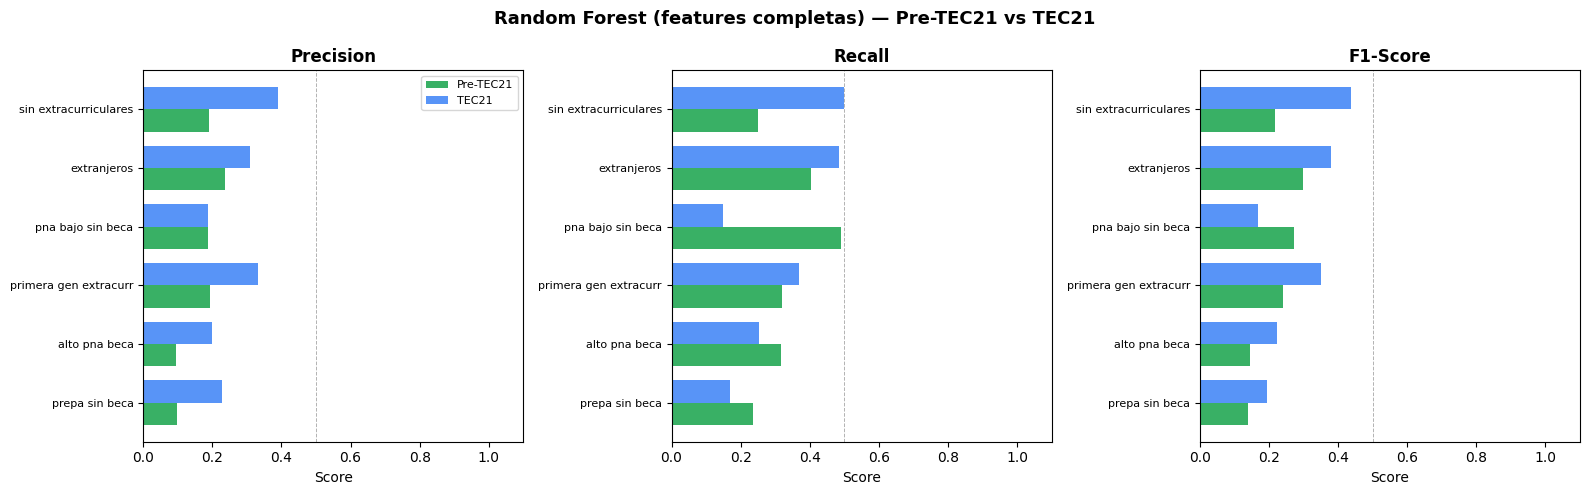

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Random Forest (features completas) — Pre-TEC21 vs TEC21', fontsize=13, fontweight='bold')

for ax, col, label in zip(axes, ['precision','recall','f1'], ['Precision','Recall','F1-Score']):
    pre_vals = metrics_pre[col].values
    tec_vals = metrics_tec[col].values
    pre_labs = [c.split('_',1)[1].replace('_',' ') for c in metrics_pre.index]
    bh = 0.38
    y_pre = np.arange(len(pre_vals))
    y_tec = np.arange(len(tec_vals)) + bh
    ax.barh(y_pre, pre_vals, height=bh, color='#16a34a', alpha=0.85, label='Pre-TEC21')
    ax.barh(y_tec, tec_vals, height=bh, color='#3b82f6', alpha=0.85, label='TEC21')
    ax.set_yticks(y_pre + bh/2)
    ax.set_yticklabels(pre_labs, fontsize=8)
    ax.set_xlim(0, 1.1)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score')
    if col == 'precision': ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Matrices de Confusión

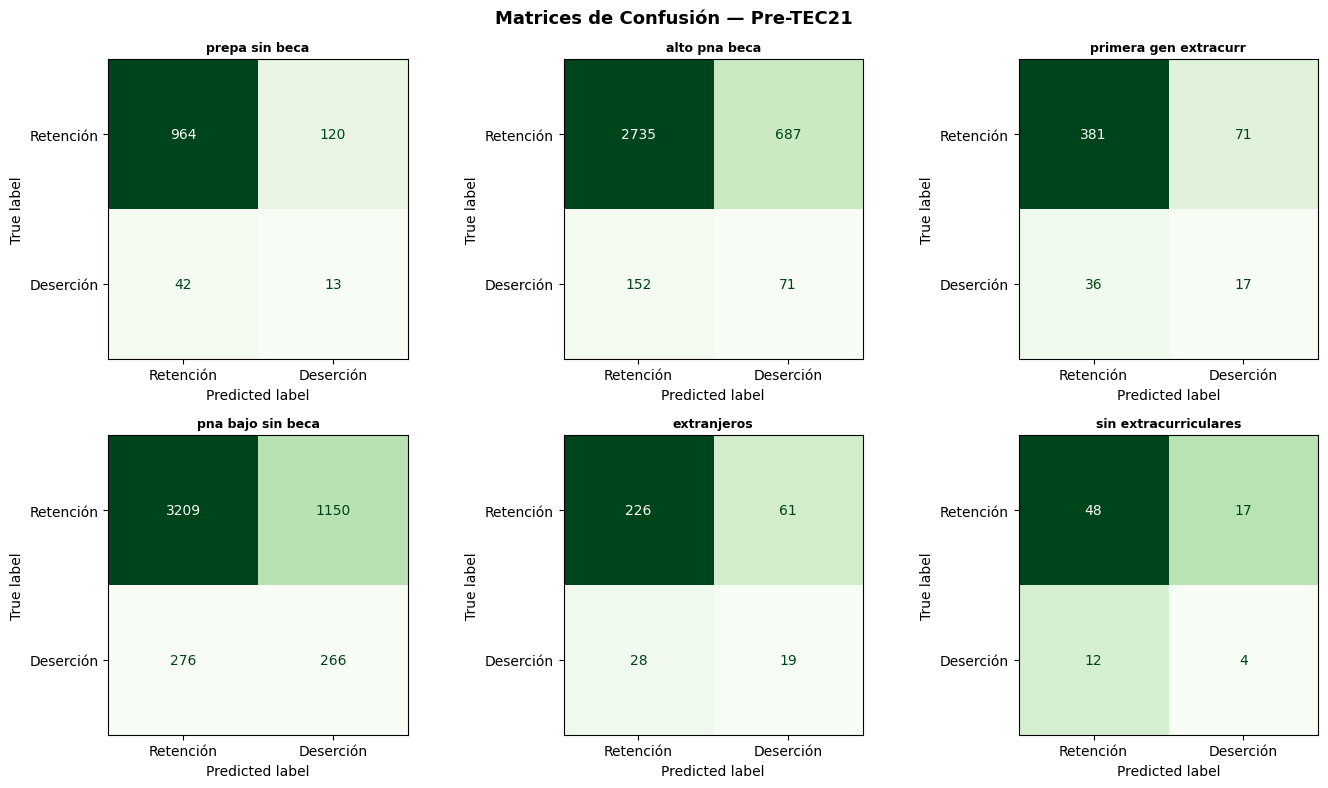

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Matrices de Confusión — Pre-TEC21', fontsize=13, fontweight='bold')
for ax, cl in zip(axes.flat, clusters_pre):
    r = models_pre[cl]
    cm = confusion_matrix(r['y_te'], r['rf'].predict(r['X_te']))
    ConfusionMatrixDisplay(cm, display_labels=['Retención','Deserción']).plot(
        ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

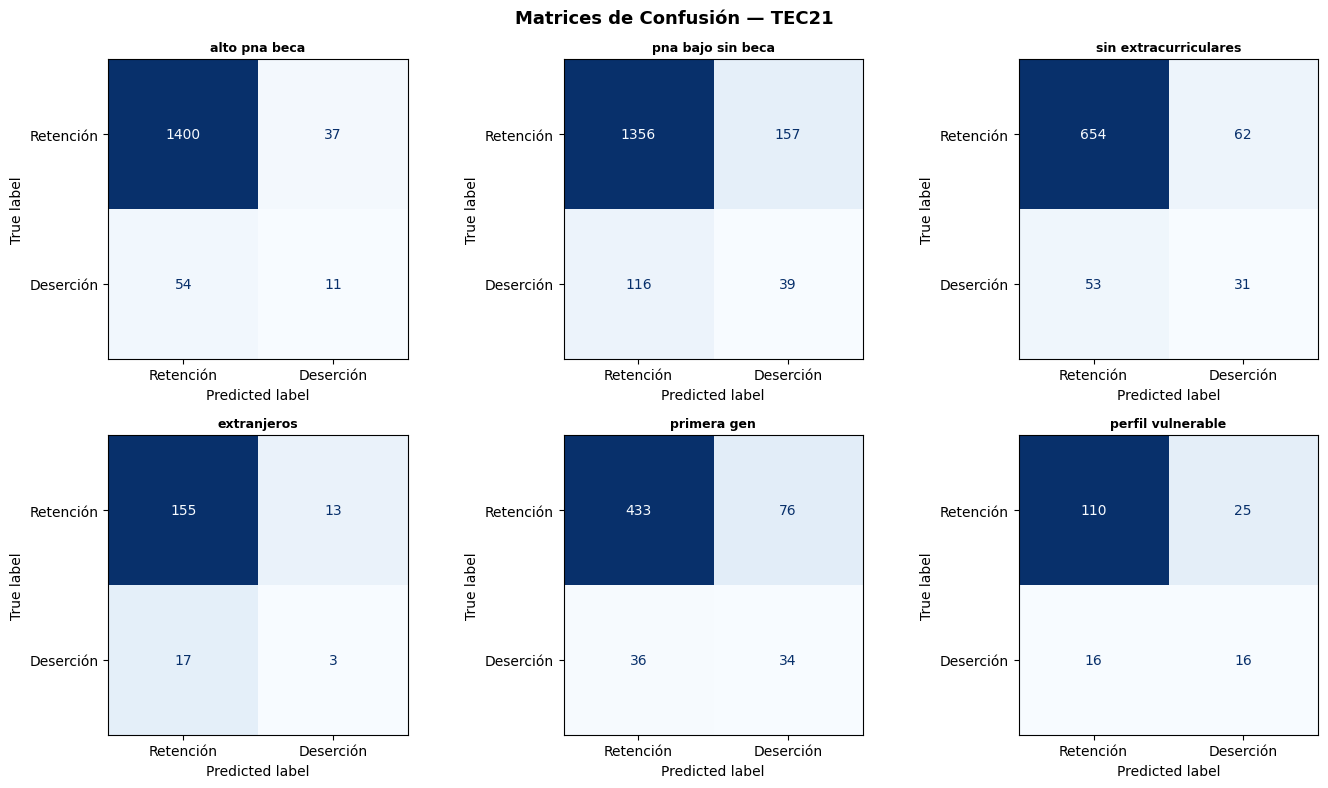

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Matrices de Confusión — TEC21', fontsize=13, fontweight='bold')
for ax, cl in zip(axes.flat, clusters_tec):
    r = models_tec[cl]
    cm = confusion_matrix(r['y_te'], r['rf'].predict(r['X_te']))
    ConfusionMatrixDisplay(cm, display_labels=['Retención','Deserción']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. SHAP — Top 10 Variables más Influyentes por Cluster
`mean(|SHAP|)` sobre el conjunto de test. Solo se muestran las 10 más importantes.

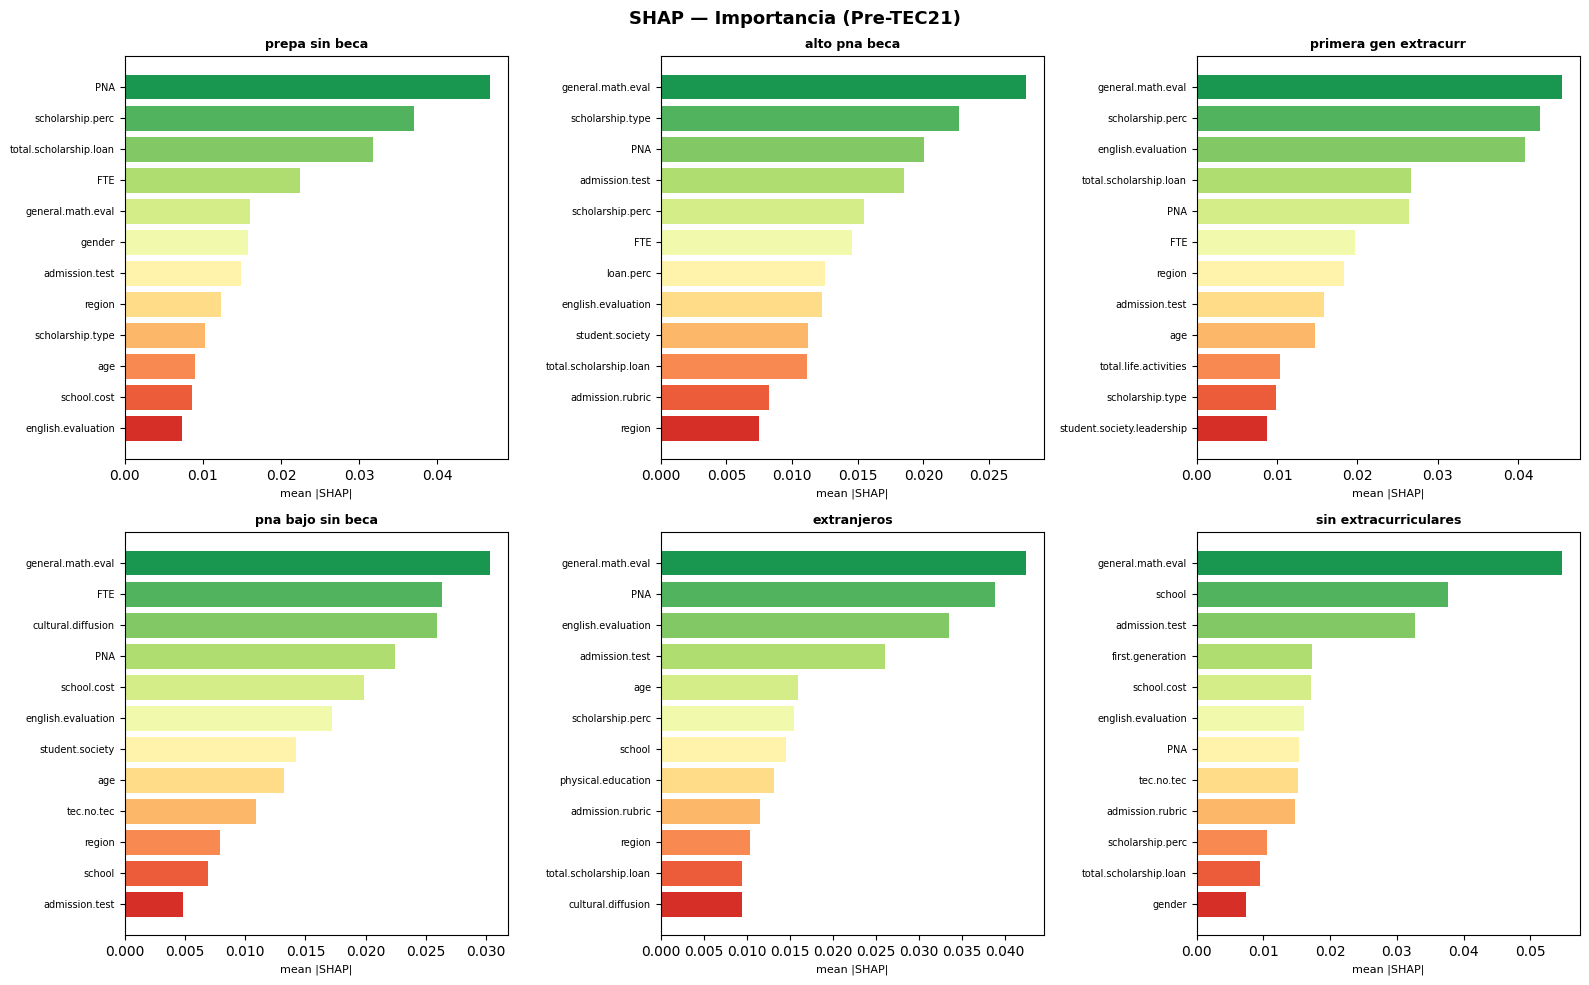

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SHAP — Importancia (Pre-TEC21)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_pre):
    r  = models_pre[cl]
    ms = np.abs(r['shap']).mean(axis=0)
    top_idx = np.argsort(ms)[::-1][:12]
    vals = ms[top_idx]
    labs = [r['feat_names'][i] for i in top_idx]
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(vals)))
    ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labs, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('mean |SHAP|', fontsize=8)

plt.tight_layout(); plt.show()

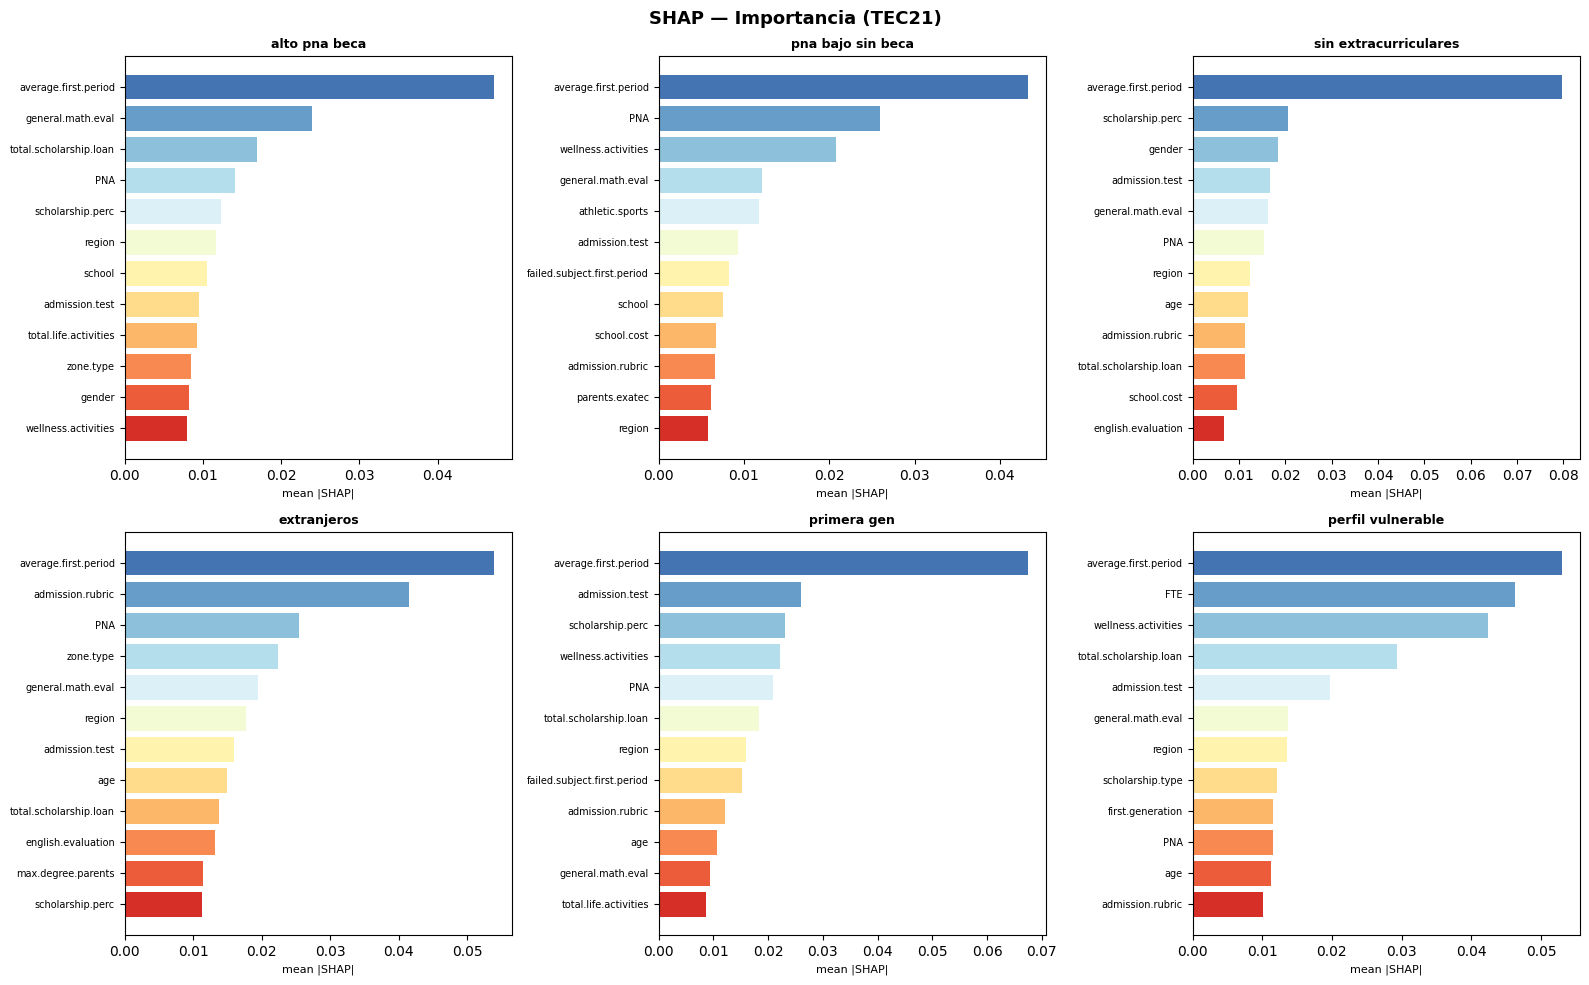

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SHAP — Importancia (TEC21)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_tec):
    r  = models_tec[cl]
    ms = np.abs(r['shap']).mean(axis=0)
    top_idx = np.argsort(ms)[::-1][:12]
    vals = ms[top_idx]
    labs = [r['feat_names'][i] for i in top_idx]
    colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(vals)))
    ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labs, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('mean |SHAP|', fontsize=8)

plt.tight_layout(); plt.show()

---
## 9. SHAP Beeswarm — Dirección del Efecto
**Rojo** = valor alto de la variable | **Azul** = valor bajo.
Positivo (derecha) → empuja hacia **deserción** | Negativo (izquierda) → hacia **retención**.

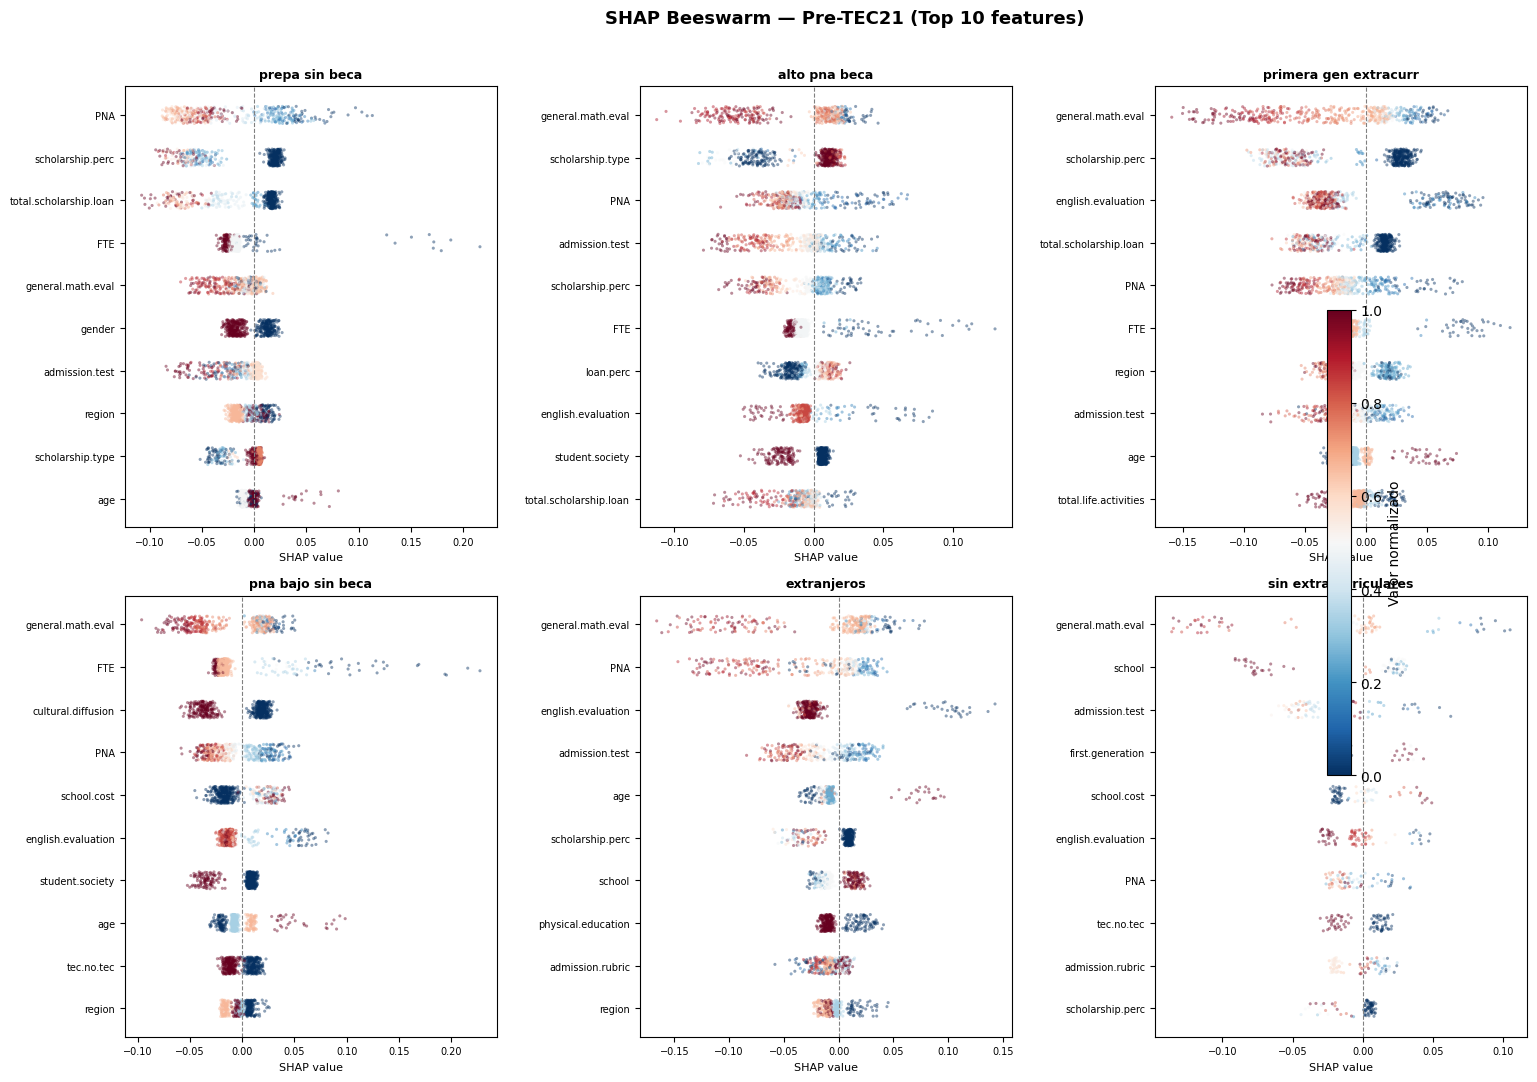

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('SHAP Beeswarm — Pre-TEC21 (Top 10 features)', fontsize=13, fontweight='bold')
for ax, cl in zip(axes.flat, clusters_pre):
    r = models_pre[cl]
    custom_beeswarm(ax, r['shap'], r['X_te_shap'], r['feat_names'],
                    cl.split('_',1)[1].replace('_',' '))
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(0,1))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Valor normalizado', shrink=0.55, pad=0.02)
plt.tight_layout(rect=[0,0,0.91,0.97]); plt.show()

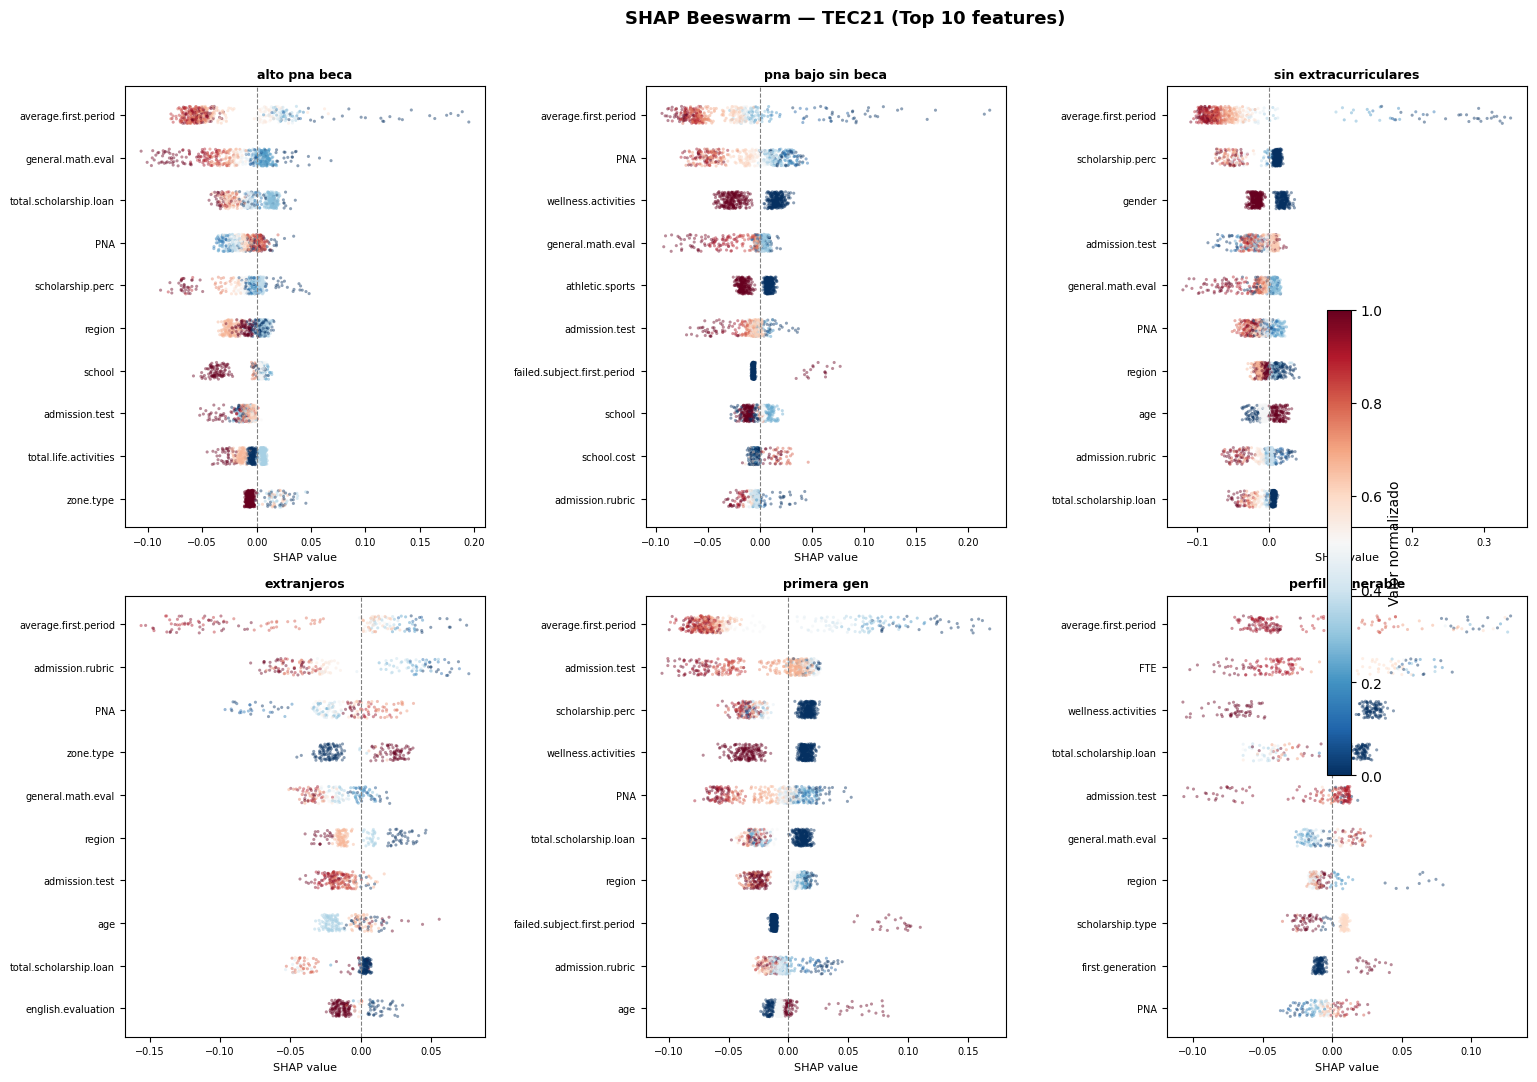

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('SHAP Beeswarm — TEC21 (Top 10 features)', fontsize=13, fontweight='bold')
for ax, cl in zip(axes.flat, clusters_tec):
    r = models_tec[cl]
    custom_beeswarm(ax, r['shap'], r['X_te_shap'], r['feat_names'],
                    cl.split('_',1)[1].replace('_',' '))
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(0,1))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Valor normalizado', shrink=0.55, pad=0.02)
plt.tight_layout(rect=[0,0,0.91,0.97]); plt.show()

---
## 10. Resumen Consolidado

In [14]:
def print_summary(mdf, label):
    print("=" * 82)
    print(f"{label} — Random Forest (features completas del dataset original)")
    print("=" * 82)
    print(f"{'Cluster':<38} {'n':>7} {'Feats':>6} {'Drop%':>6} {'Prec':>8} {'Recall':>8} {'F1':>8} {'AUC':>8}")
    print("-" * 82)
    for _, r in mdf.reset_index().iterrows():
        print(f"{r.cluster:<38} {r.n:>7,} {r.n_feats:>6} {r.dropout_rate:>5.1%} "
              f"{r.precision:>8.3f} {r.recall:>8.3f} {r.f1:>8.3f} {r.auc_roc:>8.3f}")
    print(f"{'PROMEDIO':<53} {'':>8} {'':>8} {mdf['f1'].mean():>8.3f} {mdf['auc_roc'].mean():>8.3f}")

print_summary(metrics_pre, 'Pre-TEC21')
print()
print_summary(metrics_tec, 'TEC21')

Pre-TEC21 — Random Forest (features completas del dataset original)
Cluster                                      n  Feats  Drop%     Prec   Recall       F1      AUC
----------------------------------------------------------------------------------
C0_prepa_sin_beca                        5,695     28  4.8%    0.098    0.236    0.138    0.667
C1_alto_pna_beca                        18,221     29  6.1%    0.094    0.318    0.145    0.634
C2_primera_gen_extracurr                 2,521     29 10.6%    0.193    0.321    0.241    0.705
C3_pna_bajo_sin_beca                    24,505     29 11.1%    0.188    0.491    0.272    0.667
C4_extranjeros                           1,667     27 14.2%    0.237    0.404    0.299    0.674
C5_sin_extracurriculares                   401     20 20.2%    0.190    0.250    0.216    0.502
PROMEDIO                                                                   0.218    0.642

TEC21 — Random Forest (features completas del dataset original)
Cluster              

In [15]:
# Top SHAP feature por cluster
print()
print("=" * 65)
print("Variable MÁS INFLUYENTE (SHAP) por Cluster")
print("=" * 65)
for label, clusters, models in [("Pre-TEC21", clusters_pre, models_pre),
                                  ("TEC21",     clusters_tec, models_tec)]:
    print(f"\n{label}:")
    for cl in clusters:
        r  = models[cl]
        ms = np.abs(r['shap']).mean(axis=0)
        ti = np.argmax(ms)
        print(f"  {cl.split('_',1)[1].replace('_',' '):<35} "
              f"→ {r['feat_names'][ti]:<32} (|SHAP|={ms[ti]:.4f})")


Variable MÁS INFLUYENTE (SHAP) por Cluster

Pre-TEC21:
  prepa sin beca                      → PNA                              (|SHAP|=0.0467)
  alto pna beca                       → general.math.eval                (|SHAP|=0.0278)
  primera gen extracurr               → general.math.eval                (|SHAP|=0.0454)
  pna bajo sin beca                   → general.math.eval                (|SHAP|=0.0303)
  extranjeros                         → general.math.eval                (|SHAP|=0.0424)
  sin extracurriculares               → general.math.eval                (|SHAP|=0.0547)

TEC21:
  alto pna beca                       → average.first.period             (|SHAP|=0.0472)
  pna bajo sin beca                   → average.first.period             (|SHAP|=0.0433)
  sin extracurriculares               → average.first.period             (|SHAP|=0.0796)
  extranjeros                         → average.first.period             (|SHAP|=0.0539)
  primera gen                         → averag

---
## 11. Interpretación de Resultados

### ¿Por qué mejoran las métricas respecto al modelo con 8 features?

Con el dataset completo el modelo tiene acceso a variables dinámicas y contextuales
que las 8 features de clustering no capturaban:

- **`average.first.period`** y **`failed.subject.first.period`**: el desempeño académico
  del primer período es uno de los predictores más fuertes de deserción en la literatura.
- **`scholarship.perc`** / **`loan.perc`**: desagregación del apoyo financiero más precisa
  que `total.scholarship.loan` solo.
- **`socioeconomic.level`** y **`social.lag`**: contexto socioeconómico del municipio de origen.
- **`school.cost`** y **`scholarship.type`**: tipo de apoyo financiero recibido.
- **`zone.type`**: origen urbano/rural del estudiante.

### ¿Qué significa que la misma variable domine en Pre-TEC21 y TEC21?

Si `average.first.period` aparece como top SHAP en ambos regímenes para clusters
equivalentes, es evidencia de **invarianza**: el mecanismo que predice la deserción
(rendimiento académico inicial) no cambió entre modelos educativos.

Si en cambio variables distintas dominan por régimen (ej. actividades extracurriculares
adquieren mayor peso en TEC21), sugiere **reconfiguración**: el nuevo modelo pedagógico
cambió qué factores protegen o exponen a los estudiantes.

### Limitaciones

- `average.first.period` podría tener leakage leve para desertores de primer semestre.
- OrdinalEncoder en categóricas asume orden implícito — para análisis definitivo
  usar OneHotEncoder o embeddings.
- Clusters pequeños (C4 extranjeros n=1,667; C5 Pre n=401) tienen mayor varianza en métricas.